# 05 — Postcard from Deep Time

**Where was YOUR town, hundreds of millions of years ago?**

This is the capstone notebook — pick a real Australian place, pick a time,
and make your own postcard showing where that spot used to be on planet
Earth.

*Part of **Deep Time Explorers** — a Year 4 spin-off of the [GPlately + pyGMT tutorial suite](https://github.com/EarthByte/GPlately-pyGMT-tutorials), developed by the EarthByte Group, University of Sydney — prototype stage, not yet classroom-tested.*


## Before you start

Run the cell below first.

In [1]:
# Housekeeping — checks the data files this notebook needs are present.
# If this is the first time anyone has opened Deep Time Explorers, a grown-up
# needs to run export_data.py once (see the suite README) before this will work.
from pathlib import Path
import os as _os

if Path("../data").exists() and not Path("data").exists():
    _os.chdir("..")

_required = [
    "data/towns_through_time.csv",
    "data/basemap_0Ma.png",
    "data/basemap_50Ma.png",
    "data/basemap_100Ma.png",
    "data/basemap_150Ma.png",
    "data/basemap_200Ma.png",
    "data/basemap_250Ma.png",
    "data/basemap_300Ma.png",
]
_missing = [f for f in _required if not Path(f).exists()]
if _missing:
    raise FileNotFoundError(
        "Missing data file(s): " + ", ".join(_missing) +
        "\n\nAsk a grown-up to run export_data.py once from the "
        "deep-time-explorers folder — see README.md. "
    )
print("All data files found — ready to go!")


All data files found — ready to go!


In [2]:
# The only packages this notebook needs — all standard, nothing to install
# beyond a normal Jupyter setup.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, IntSlider, SelectionSlider, Dropdown


In [3]:
# --- Robinson world-map helpers -------------------------------------------
# These four numbers describe the exact shape of a full-globe "Robinson"
# map projection (the curved world-map style used below). They're always
# the same no matter what age we're looking at, so we only need to write
# them once. export_data.py used the exact same numbers when it made the
# background pictures, so everything lines up perfectly.
ROBINSON_EXTENT = (-20464646.889276125, 17966614.874622703, -10991340.864475066, 10145853.105669294)

def show_basemap(ax, age_ma):
    """Draw the real paleo-elevation world map for a given age. Green/tan
    shows low land, browns and white show mountains — the SAME kind of
    colouring you'd see on a real physical-geography map today."""
    img = plt.imread(f"data/basemap_{int(age_ma)}Ma.png")
    ax.imshow(img, extent=ROBINSON_EXTENT, origin="upper")
    ax.set_xlim(ROBINSON_EXTENT[0], ROBINSON_EXTENT[1])
    ax.set_ylim(ROBINSON_EXTENT[2], ROBINSON_EXTENT[3])
    ax.set_xticks([]); ax.set_yticks([])
    ax.axis("off")


In [4]:
towns = pd.read_csv("data/towns_through_time.csv")
print("Places you can choose from:")
for t in sorted(towns["town"].unique()):
    print(" -", t)


Places you can choose from:
 - Adelaide
 - Alice Springs
 - Austinmer
 - Brisbane
 - Cairns
 - Canberra
 - Darwin
 - Hobart
 - Melbourne
 - Perth
 - Sydney


## Make your postcard

Pick a **town** and an **age**, then run the next cell.

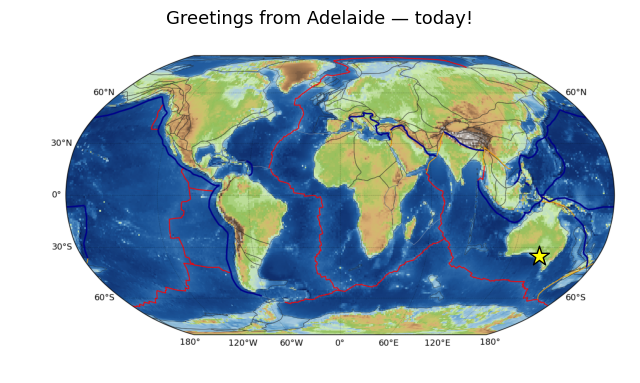

Saved as postcard_Adelaide_0Ma.png
(Back then, Adelaide sat at about -34.9 degrees latitude, 138.6 degrees longitude.)


interactive(children=(Dropdown(description='Place:', options=('Adelaide', 'Alice Springs', 'Austinmer', 'Brisb…

In [5]:
AGES = [0, 50, 100, 150, 200, 250, 300]

def make_postcard(town, age_ma):
    row = towns[(towns.town == town) & (towns.age_ma == age_ma)].iloc[0]
    fig, ax = plt.subplots(figsize=(8, 5.5))
    show_basemap(ax, age_ma)
    ax.scatter([row.robinson_x], [row.robinson_y], color="yellow", edgecolor="black",
               s=220, marker="*", zorder=6)
    caption = (f"Greetings from {town}, {age_ma} million years ago!"
               if age_ma else f"Greetings from {town} — today!")
    ax.set_title(caption, fontsize=13)
    fig.savefig(f"postcard_{town.replace(' ', '_')}_{age_ma}Ma.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved as postcard_{town.replace(' ', '_')}_{age_ma}Ma.png")
    print(f"(Back then, {town} sat at about {row.lat:.1f} degrees latitude, {row.lon:.1f} degrees longitude.)")

# One example postcard as a plain static picture -- shows up even where the
# dropdown/slider below can't run (like GitHub's preview). Pick any town and
# age you like below.
make_postcard("Adelaide", 0)
interact(make_postcard,
         town=Dropdown(options=sorted(towns["town"].unique()), description="Place:"),
         age_ma=SelectionSlider(options=AGES, description="Time:"));


## Share your postcard!

Your postcard has been saved as a `.png` file — ask a grown-up to help you
find it, print it out, or add it to a class display. Try making one for a
few different places and ages, and compare how far each one has travelled.

## Try this next!

- Add your own home town! (A grown-up can add it to `export_data.py`'s town list and re-run it.)
- Add a short story to your postcard caption — what do you think the weather or the wildlife was like there back then? (Notebook 6 can help you check!)
- Compare two different towns at the very same age — were they closer together or further apart than they are today?

---
*Part of **Deep Time Explorers** — a Year 4 spin-off of the [GPlately + pyGMT tutorial suite](https://github.com/EarthByte/GPlately-pyGMT-tutorials), developed by the EarthByte Group, University of Sydney — prototype stage, not yet classroom-tested.*
